In [6]:
# Add src to path to allow importing net_epistemology without installing the package
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [7]:
from net_epistemology.utils.imports import *
from net_epistemology.core.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

In [8]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../data/empirical_networks/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../data/empirical_networks/pud_final.json


In [9]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [10]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=100000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 100000/100000 [01:06<00:00, 1504.86it/s]


steps:  100000
conclusion:  0.6442307692307693
conclusion core 0.8602941176470589


,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,0.879171,0.413108,0.863912,0.44165,0.045605,0.039208,0.633264,0.871281,0.744978,0.637206,...,0.572166,0.675556,0.409384,0.359543,0.514395,0.797037,0.876221,0.856987,0.678327,0.107761
1,0.876599,0.413108,0.864850,0.44165,0.045605,0.038314,0.627673,0.870381,0.751010,0.637206,...,0.562347,0.673800,0.415200,0.348566,0.512396,0.798329,0.877086,0.856987,0.678327,0.109309
2,0.880019,0.413108,0.866709,0.44165,0.045605,0.038908,0.627673,0.872176,0.749511,0.639053,...,0.556432,0.673800,0.411320,0.355867,0.514395,0.798329,0.877946,0.856987,0.676579,0.110090


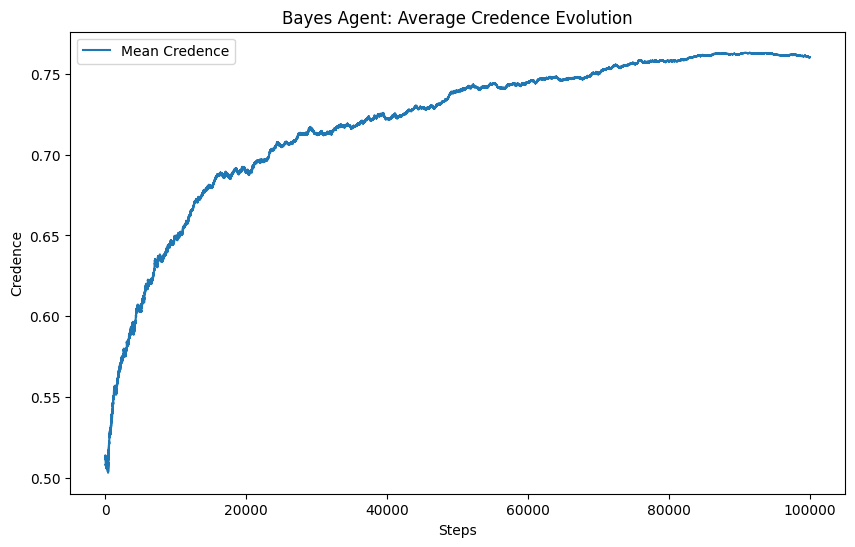

In [11]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [12]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:09<00:00, 1067.51it/s]


steps:  10000
conclusion:  0.5608974358974359


,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,"[0.648738940239359, 0.4189303602323111]","[0.15523929416187998, 0.9999999973064337]","[0.9995504380902542, 0.0033692575244019278]","[0.6067585213320673, 0.7923048077949436]","[0.3772888794504239, 0.9999339050897295]","[0.9466846502357353, 0.3480225981558622]","[0.8445813519081494, 0.21908953256537247]","[0.9814989315487189, 7.860824061209597e-05]","[0.40734903931070454, 0.4120492510049537]","[0.9640040874115168, 0.7088120407193524]",...,"[0.6354316191177422, 1.3012120428158289e-05]","[0.6700582846870184, 0.818633436490088]","[0.43383448896950183, 0.05538836787690562]","[0.4039783067497114, 0.8595508679219802]","[0.007225412002398146, 0.3193612627953228]","[0.512453845099366, 0.19534244671862333]","[0.8562215913305111, 0.5291319089935226]","[0.5981697094773782, 0.6104725880734448]","[0.7021756634700868, 0.4617297763482826]","[0.7422783816456627, 0.0007832059575332767]"
1,"[0.48990182709926905, 0.5861562097346782]","[0.19807207388362924, 0.7207954376569657]","[0.5532289630110392, 0.0007496277395706821]","[0.38283781076273304, 0.6156071429880817]","[0.3253103829391495, 0.74923072556272]","[0.7255363348669202, 0.49826561759796684]","[0.4760276451886275, 0.5833920439873522]","[0.40831481015993043, 0.5167226702236436]","[0.5191844462555623, 0.33667174233556696]","[0.6045763215326537, 0.5306684607867569]",...,"[0.6459008289953272, 0.5645888788458118]","[0.4438964938500954, 0.482890405715684]","[0.5268224235162575, 0.6904469571602276]","[0.42216970237747836, 0.5749536129740711]","[0.0006178853165279041, 0.6446139748013401]","[0.7599354527594404, 0.7249671457849767]","[0.6583851259532502, 0.333948263395589]","[0.7438417345201864, 0.5390772703512201]","[0.6295323853539062, 0.8593579871505234]","[0.5956088706556787, 0.2760190521841634]"
2,"[0.6835313553844229, 0.5678690487324599]","[0.40249748415875863, 0.7366065530542255]","[0.5912841891530686, 1.6851145839869617e-07]","[0.479935888839192, 0.5975117501126712]","[0.3352142652695505, 0.6537456216141876]","[0.5560574575346182, 0.5689516802154699]","[0.6229564660491824, 0.3942197190628773]","[0.4567671869410644, 0.49214025388759475]","[0.40947760533691036, 0.4143752252814645]","[0.6144926007999572, 0.48727671114133625]",...,"[0.42425740647486965, 0.5340580955989535]","[0.4903865296588577, 0.32915413362911533]","[0.4265905151870444, 0.3156105801825933]","[0.4466953481249276, 0.3497584170866741]","[0.000372413501186432, 0.41895105325145376]","[0.7725284491439377, 0.31447313621777684]","[0.519511558576455, 0.14995838050184798]","[0.35375345951352705, 0.535498755697567]","[0.5805965778876735, 0.6693831239220338]","[0.586120236784113, 0.28408931770908413]"


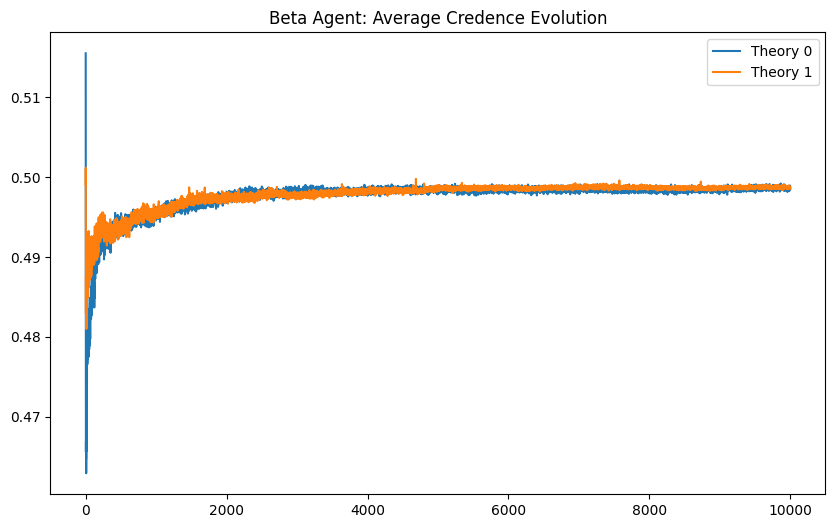

In [13]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

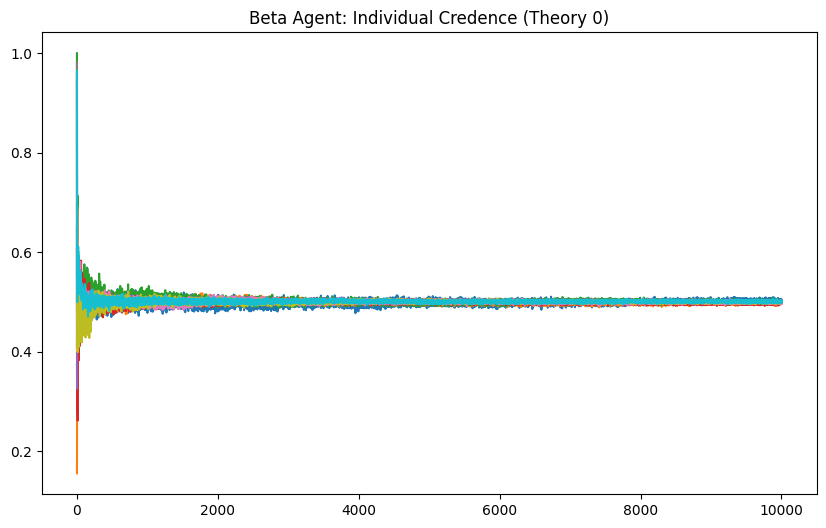

In [14]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()